# Algorithm for triangular inverse on cube unit

In [1]:
import numpy as np
from numpy.linalg import inv
 
def is_power_of_2(c):
    return (c != 0) and (c & (c-1) == 0)
 
def strict_lower(c=4, seed=0):
    # return np.tril(np.random.rand(c, c), k=-1)
    L = np.tril(0.5*np.ones((c, c)))
    L = L - 0.5*np.identity(c)
    return L
 
def inv_trick(A):
    """
    Compute (I + A)^{-1} without explicit inversion
    """
    assert A.ndim == 2 and A.shape[0] == A.shape[1]
    c = A.shape[0]
    assert is_power_of_2(c) and c >= 4
    log2_c = int(np.log2(c))
    I = np.eye(c)
    X, Y = (I - A, A @ A)
    for i in range(log2_c - 1):
        X, Y = (X + X @ Y, Y @ Y)
    return X
 
def inv_recurse(A):
    # Reference: Section 3.1 in Demmel et al https://arxiv.org/pdf/math/0612264
    n = A.shape[0]
    A_inv = np.zeros(A.shape, dtype=A.dtype)
    A11 = A[0:n//2,0:n//2]
    A22 = A[n//2:,n//2:]
    A21 = A[n//2:,0:n//2]
    if n//2 > 4:
        A_inv[0:n//2,0:n//2] = inv_recurse(A11)
        A_inv[n//2:,n//2:] = inv_recurse(A22)
    else:
        A_inv[0:n//2,0:n//2] = inv_trick(A11)
        A_inv[n//2:,n//2:] = inv_trick(A22)
    A_inv[n//2:,0:n//2] = - A_inv[n//2:,n//2:] @ A21 @ A_inv[0:n//2,0:n//2] 
    return A_inv
 
def inv_rec_unroll_naive(A):
    dtype = A.dtype
    def left_blocks(A, block_size):
        B = np.identity(A.shape[0], dtype=dtype)
        for idx in range(0, n, 2*block_size):
            B[idx:idx+block_size,idx:idx+block_size] = A[idx:idx+block_size,idx:idx+block_size]
        return B
    def right_blocks(A, block_size):
        B = np.identity(A.shape[0], dtype=dtype)
        for idx in range(block_size, n, 2*block_size):
            B[idx:idx+block_size,idx:idx+block_size] = A[idx:idx+block_size,idx:idx+block_size]
        return B
    def mid_blocks(A, block_size):
        B = np.identity(A.shape[0], dtype=dtype)
        for idx in range(0, n, 2*block_size):
            B[idx:idx+block_size,idx+block_size:idx+2*block_size] = -A[idx:idx+block_size,idx+block_size:idx+2*block_size]
        return B
 
    n = A.shape[0]
    A = np.identity(n, dtype=dtype) + A
    block_size = 1
    l_blocks = left_blocks(A, block_size)
    r_blocks = right_blocks(A, block_size)
    m_blocks = mid_blocks(A, block_size)
    B = l_blocks @ m_blocks @ r_blocks
    block_size = block_size * 2
    while block_size < n:
        l_blocks = left_blocks(B, block_size)
        r_blocks = right_blocks(B, block_size)
        m_blocks = mid_blocks(A, block_size)
        B = l_blocks @ m_blocks @ r_blocks
        block_size = block_size * 2
    return B
 
 

In [2]:

n_values = [8, 16, 32, 64, 128]
dtype = np.float16

def prepare_block_masks(this_n, dtype):
    zeros = np.zeros((this_n, this_n), dtype=dtype)
    ones = np.ones((this_n, this_n), dtype=dtype)
    left_block_masks = {1: zeros}
    right_block_masks = {1: zeros}
    mid_block_masks = {1: zeros}
    block_sizes = [2 ** p for p in range(int(np.log2(this_n)))]
    for b in block_sizes:
        L = zeros.copy()
        for k in range(0, this_n, 2*b):
            L[k:k + b, k:k + b] = ones[k:k + b, k:k + b]
        left_block_masks[b] = L

        R = zeros.copy()
        for k in range(b, this_n-1, 2*b):
            R[k:k + b, k:k + b] = ones[k:k + b, k:k + b]
        right_block_masks[b] = R

        M = zeros.copy()
        for k in range(0, this_n-1, 2*b):
            M[k:k + b, k + b:k + 2 * b] = ones[k:k + b, k:k + b]
        mid_block_masks[b] = M
    return left_block_masks, right_block_masks, mid_block_masks

Lmask = dict()
Rmask = dict()
Mmask = dict()
for n in n_values:
    Lmask[n], Rmask[n], Mmask[n] = prepare_block_masks(n,dtype=dtype)

def inv_rec_unroll(A):
    # sounds like "inv rock-n-roll-a" https://www.imdb.com/de/title/tt1032755/
    dtype = A.dtype
 
    n = A.shape[0]
    I = np.identity(n, dtype=dtype)
    block_size = 1
    M = Mmask[n][block_size]
    B = - M * A + I
    block_size = block_size * 2
    while block_size < n:
        L = Lmask[n][block_size]
        R = Rmask[n][block_size]
        M = Mmask[n][block_size]
        LB = L * B 
        RB = R * B 
        MA = - M * A
        B = LB @ MA @ RB
        B = B + LB + RB
        block_size = block_size * 2
    return B



%
% dtype: fp16
% error formula: ||A_inv_true - A_inv_result||_F / ||A_inv_true||_F
%
size = 8x8
size = 16x16
size = 32x32
size = 64x64


/tmp/ipykernel_3503755/3169302301.py:24: RuntimeWarning: overflow encountered in matmul
  X, Y = (X + X @ Y, Y @ Y)
/tmp/ipykernel_3503755/3169302301.py:24: RuntimeWarning: invalid value encountered in matmul
  X, Y = (X + X @ Y, Y @ Y)


size = 128x128


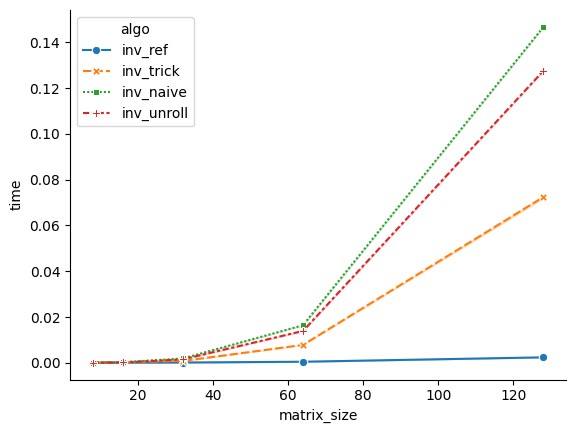

matrix_size,8,16,32,64,128
algo,,,,,
inv_naive,0.000e+00,0.000e+00,1.367e-08,2.323e-08,2.673e-08
inv_trick,0.000e+00,0.000e+00,5.009e-01,nan,nan
inv_unroll,0.000e+00,0.000e+00,1.367e-08,2.323e-08,2.673e-08


In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

max_iters = 5
algos = ['inv_ref', 'inv_trick', 'inv_naive', 'inv_unroll']

if __name__=="__main__":
    print("%")
    print("% dtype: fp16")
    print("% error formula: ||A_inv_true - A_inv_result||_F / ||A_inv_true||_F")
    print("%")

    times_data = {'algo': [], 'matrix_size': [], 'time': []}
    error_data = {'algo': [], 'matrix_size': [], 'error': []}
    for c in n_values:
        print("===============")
        print(f"size = {c}x{c}")
        A = strict_lower(c).astype(dtype)

        algo = 'inv_ref'
        for _ in range(max_iters):
            t = time.time()
            A_inv_ref = inv((A + np.eye(c)).astype(np.float64))
            t = time.time()-t
            times_data['algo'].append(algo)
            times_data['matrix_size'].append(c)
            times_data['time'].append(t)
                
        algo = 'inv_trick'
        for _ in range(max_iters):
            t = time.time()
            A_inv = inv_trick(A)
            t = time.time()-t
            times_data['algo'].append(algo)
            times_data['matrix_size'].append(c)
            times_data['time'].append(t)
        error_data['algo'].append(algo)
        error_data['matrix_size'].append(c)
        error_data['error'].append(np.linalg.norm(A_inv - A_inv_ref, "fro") / np.linalg.norm(A_inv_ref,"fro"))

        algo = 'inv_naive'
        for _ in range(max_iters):
            t = time.time()
            A_inv = inv_rec_unroll_naive(A.T).T
            t = time.time()-t
            times_data['algo'].append(algo)
            times_data['matrix_size'].append(c)
            times_data['time'].append(t)
        error_data['algo'].append(algo)
        error_data['matrix_size'].append(c)
        error_data['error'].append(np.linalg.norm(A_inv - A_inv_ref, "fro") / np.linalg.norm(A_inv_ref,"fro"))


        algo = 'inv_unroll'
        for _ in range(max_iters):
            t = time.time()
            A_inv_unroll = inv_rec_unroll(A.T).T
            t = time.time()-t
            times_data['algo'].append(algo)
            times_data['matrix_size'].append(c)
            times_data['time'].append(t)
        error_data['algo'].append(algo)
        error_data['matrix_size'].append(c)
        error_data['error'].append(np.linalg.norm(A_inv - A_inv_ref, "fro") / np.linalg.norm(A_inv_ref,"fro"))

    # fig, ax = plt.subplots()
    times_df = pd.DataFrame(times_data)
    sns.lineplot(times_df, x='matrix_size', y='time', hue='algo', style='algo', markers=True, errorbar=('ci', 95), err_style='band')
    plt.show()

    error_df = pd.DataFrame(error_data)
    pivot_table = error_df.pivot(index='algo', columns='matrix_size', values='error')
    styled_table = pivot_table.style.format('{:.3e}')
    styled_table = styled_table.set_caption('Frobenius norm relative error')
    display(styled_table)
    
